<a href="https://colab.research.google.com/github/feelsmandata/GoogleColabProjects/blob/main/Flood_Risk_Impact_on_Property_Value_Trends_in_Camarines_Sur_(2023%E2%80%932025)_with_Quarterly_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install faker

In [ ]:
#THE DATA BEING USED IN THIS ANALYSIS IS DUMMY FROM FAKER MODULE. THE DATA WILL SERVE AS INTENDED, NOTHING MORE, NOTHING LESS.

In [ ]:
import pandas as pd
import geopandas as gpd
from faker import Faker
import numpy as np
import prophet
import random
from datetime import datetime

In [ ]:
fake = Faker()

In [ ]:
lat_min, lat_max = 13.3, 14.2
lon_min, lon_max = 122.5,123.4

camsur_locations = ["Naga City", "Iriga City","Pili","Calabanga","Libmanan","Tinambac","Canaman","Magarao","Camaligan","Gainza"]
flood_prone_areas = ["Naga City", "Iriga City","Pili","Calabanga","Libmanan","Tinambac","Canama"]

In [ ]:
def get_flood_risk(city, rainfall,elevation):
  if city in flood_prone_areas and rainfall > 150 and elevation < 20:
    return "High"
  elif rainfall > 120:
    return "Medium"
  else:
    return "Low"

In [ ]:
def generate_asset_value(flood_risk):
  base = random.randint(100_000,10_000_000)

  if flood_risk == "High":
    return int(base * random.uniform(0.6,0.8))
  elif flood_risk == "Medium":
    return int(base * random.uniform(0.8,0.95))
  else:
    return base

In [ ]:
start_date = datetime(2023, 1, 1)
end_date = datetime(2025, 12, 31)

chunk_size = 5000
total_rows = 50000

file_name = "camsur_flood_data.csv"

for i in range(0, total_rows, chunk_size):
    data = []

    for j in range(chunk_size):
        city = random.choice(camsur_locations)

        lat = random.uniform(lat_min, lat_max)
        lon = random.uniform(lon_min, lon_max)

        rainfall = random.uniform(50, 300)
        elevation = random.uniform(1, 100)

        flood_risk = get_flood_risk(city, rainfall, elevation)
        asset_value = generate_asset_value(flood_risk)

        data.append({
            "id": i + j,
            "name": fake.name(),
            "address": f"{fake.street_address()}, {city}, Camarines Sur",
            "city": city,
            "latitude": lat,
            "longitude": lon,
            "date": fake.date_between(start_date=start_date, end_date=end_date),
            "rainfall_mm": rainfall,
            "elevation": elevation,
            "flood_risk": flood_risk,
            "asset_value": asset_value
        })

    df_chunk = pd.DataFrame(data)

    df_chunk.to_csv(
        file_name,
        mode='a',
        index=False,
        header=(i == 0)
    )

    print(f"Saved {i + chunk_size} rows")


Saved 5000 rows
Saved 10000 rows
Saved 15000 rows
Saved 20000 rows
Saved 25000 rows
Saved 30000 rows
Saved 35000 rows
Saved 40000 rows
Saved 45000 rows
Saved 50000 rows


In [ ]:
#AFTER GENERATING DUMMY DATA FROM FAKER MODULE. WE WILL NOW CREATE SAMPLE QUARTERLY INSIGHTS

In [ ]:
file = '/content/drive/MyDrive/Data Analyst Portfolio/Github Portfolio/Flood Risk Impact/camsur_flood_data.csv'

In [ ]:
def read_file(filename):
  if filename.endswith('.csv'):
    return pd.read_csv(filename)
  elif filename.endswith('.xlsx'):
    return pd.read_excel(filename)
  elif filename.endswith('.parquet'):
    return pd.read_parquet(filename)
  else:
    print('Please enter valid file extension')

In [ ]:
df = read_file(file)
print(df.head(5))

   id                 name                                            address  \
0   0      Matthew Collins          9925 Carol Ports, Tinambac, Camarines Sur   
1   1  Alexander Blackburn       56620 Leslie Court, Naga City, Camarines Sur   
2   2   Christopher Lowery   913 Guzman Wall Apt. 178, Canaman, Camarines Sur   
3   3      Kirsten Rosario  67523 Nancy Well Apt. 729, Camaligan, Camarine...   
4   4     Samantha Roberts          1864 Kyle Plaza, Calabanga, Camarines Sur   

        city   latitude   longitude        date  rainfall_mm  elevation  \
0   Tinambac  13.582611  123.060407  2023-07-18   185.851378  17.625918   
1  Naga City  13.471103  122.881345  2023-11-22   252.529792  12.365188   
2    Canaman  13.917262  122.756295  2023-08-03    75.814090  49.173854   
3  Camaligan  13.530654  122.915674  2023-10-15    94.747152  26.316431   
4  Calabanga  13.690190  122.712329  2024-10-14   117.264967  32.536744   

  flood_risk  asset_value  
0       High      4238975  
1     

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['quarter'] = df['date'].dt.to_period('Q')

In [ ]:
quarterly_total = df.groupby('quarter')['asset_value'].sum().reset_index()
print(quarterly_total.head(20))

   quarter  asset_value
0   2023Q1  18688387371
1   2023Q2  18340038225
2   2023Q3  19083020658
3   2023Q4  18905697878
4   2024Q1  18855610670
5   2024Q2  18597720565
6   2024Q3  18751570134
7   2024Q4  19584804559
8   2025Q1  18908567392
9   2025Q2  18265351753
10  2025Q3  19584251257
11  2025Q4  19000843650


In [ ]:
quaterly_average = df.groupby('quarter')['asset_value'].mean().reset_index()
print(quaterly_average.head(20))


   quarter   asset_value
0   2023Q1  4.513013e+06
1   2023Q2  4.476456e+06
2   2023Q3  4.564224e+06
3   2023Q4  4.486402e+06
4   2024Q1  4.564418e+06
5   2024Q2  4.561619e+06
6   2024Q3  4.496779e+06
7   2024Q4  4.528279e+06
8   2025Q1  4.593918e+06
9   2025Q2  4.502182e+06
10  2025Q3  4.617838e+06
11  2025Q4  4.470787e+06


In [ ]:
quarterly_count = df.groupby('quarter').size().reset_index(name='count')
print(quarterly_count.head(20))

   quarter  count
0   2023Q1   4141
1   2023Q2   4097
2   2023Q3   4181
3   2023Q4   4214
4   2024Q1   4131
5   2024Q2   4077
6   2024Q3   4170
7   2024Q4   4325
8   2025Q1   4116
9   2025Q2   4057
10  2025Q3   4241
11  2025Q4   4250


In [ ]:
quarterly_flood = df.groupby(['quarter', 'flood_risk'])['asset_value'].mean().reset_index()
quarterly_flood

,quarter,flood_risk,asset_value
0,2023Q1,High,3.690938e+06
1,2023Q1,Low,4.964374e+06
2,2023Q1,Medium,4.411193e+06
3,2023Q2,High,3.258202e+06
4,2023Q2,Low,5.005239e+06
5,2023Q2,Medium,4.376450e+06
6,2023Q3,High,3.774494e+06
7,2023Q3,Low,4.954006e+06
8,2023Q3,Medium,4.484656e+06
9,2023Q4,High,3.617783e+06


In [ ]:
pivot_table = quarterly_flood.pivot(index='quarter', columns='flood_risk', values='asset_value')
pivot_table

flood_risk,High,Low,Medium
quarter,,,
2023Q1,3.690938e+06,4.964374e+06,4.411193e+06
2023Q2,3.258202e+06,5.005239e+06,4.376450e+06
2023Q3,3.774494e+06,4.954006e+06,4.484656e+06
2023Q4,3.617783e+06,5.025846e+06,4.345141e+06
2024Q1,3.506068e+06,5.111687e+06,4.450353e+06
2024Q2,3.495579e+06,5.004834e+06,4.484939e+06
2024Q3,3.524750e+06,4.895494e+06,4.434447e+06
2024Q4,3.555012e+06,5.073253e+06,4.389955e+06
2025Q1,3.488928e+06,5.185821e+06,4.452785e+06


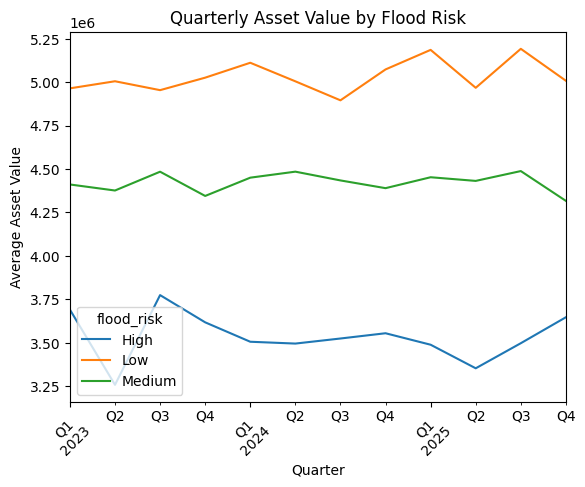

In [ ]:
import matplotlib.pyplot as plt

pivot_table.plot()
plt.title("Quarterly Asset Value by Flood Risk")
plt.xlabel("Quarter")
plt.ylabel("Average Asset Value")
plt.xticks(rotation=45)
plt.show()

In [ ]:
rainfall_trend = df.groupby('quarter')['rainfall_mm'].mean()
rainfall_trend

,rainfall_mm
quarter,
2023Q1,174.441113
2023Q2,176.268006
2023Q3,175.899375
2023Q4,175.240531
2024Q1,175.362282
2024Q2,175.213221
2024Q3,176.340732
2024Q4,174.331961
2025Q1,175.169445


In [ ]:
quarterly_total['quarter'] = quarterly_total['quarter'].astype(str)
quarterly_total['quarter'] = pd.to_datetime(quarterly_total['quarter'])


/tmp/ipykernel_254/262011660.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  quarterly_total['quarter'] = pd.to_datetime(quarterly_total['quarter'])


In [ ]:
!pip install prophet

In [ ]:
quaterly_total_prophet = quarterly_total.rename(columns={'quarter': 'ds', 'asset_value': 'y'})
quaterly_total_prophet['ds'] = pd.to_datetime(quaterly_total_prophet['ds'])
quaterly_total_prophet = quaterly_total_prophet.set_index('ds')
print(quaterly_total_prophet.head())

                      y
ds                     
2023-01-01  18688387371
2023-04-01  18340038225
2023-07-01  19083020658
2023-10-01  18905697878
2024-01-01  18855610670


In [ ]:
from prophet import Prophet

model = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)

# Reset index to make 'ds' a column again for Prophet
df_for_prophet = quaterly_total_prophet.reset_index()

model.fit(df_for_prophet)

INFO:prophet:n_changepoints greater than number of observations. Using 8.


In [ ]:
future = model.make_future_dataframe(periods=12, freq='Q')
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
14,2026-06-30,1.251868e+10,1.232889e+10,1.272554e+10
15,2026-09-30,1.871536e+10,1.842123e+10,1.904087e+10
16,2026-12-31,1.847930e+10,1.806642e+10,1.891940e+10
17,2027-03-31,2.393070e+10,2.339340e+10,2.453091e+10
18,2027-06-30,8.423013e+09,7.727156e+09,9.181357e+09
19,2027-09-30,1.840992e+10,1.753888e+10,1.933220e+10
20,2027-12-31,1.806481e+10,1.700833e+10,1.919077e+10
21,2028-03-31,1.766529e+10,1.640776e+10,1.900139e+10
22,2028-06-30,1.605021e+10,1.460525e+10,1.757660e+10
23,2028-09-30,1.707023e+10,1.537208e+10,1.883760e+10


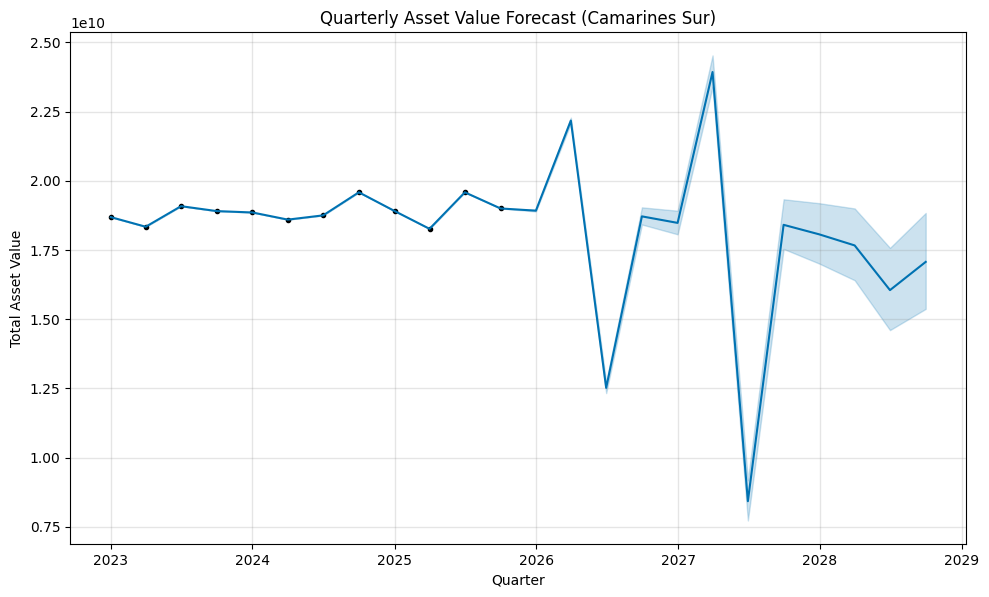

In [ ]:
from prophet.plot import plot_plotly
import matplotlib.pyplot as plt

# Matplotlib version
model.plot(forecast)
plt.title("Quarterly Asset Value Forecast (Camarines Sur)")
plt.xlabel("Quarter")
plt.ylabel("Total Asset Value")
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates = pd.date_range(


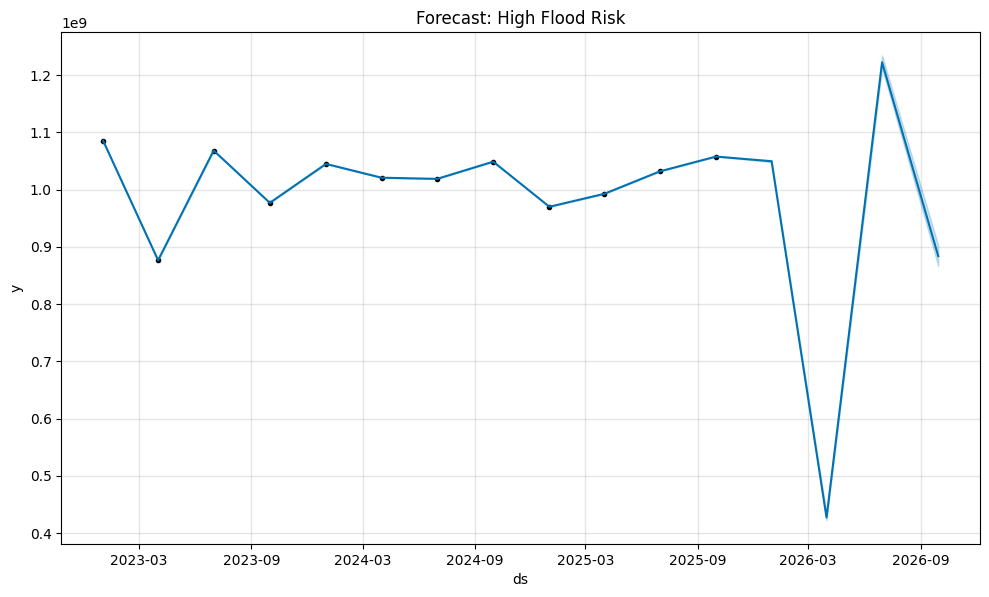

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates = pd.date_range(


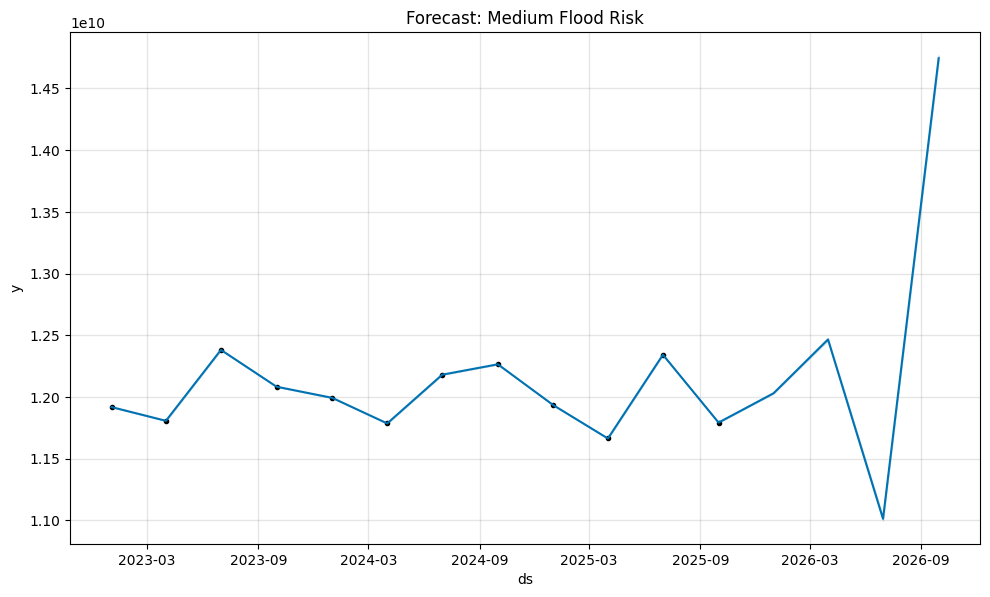

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates = pd.date_range(


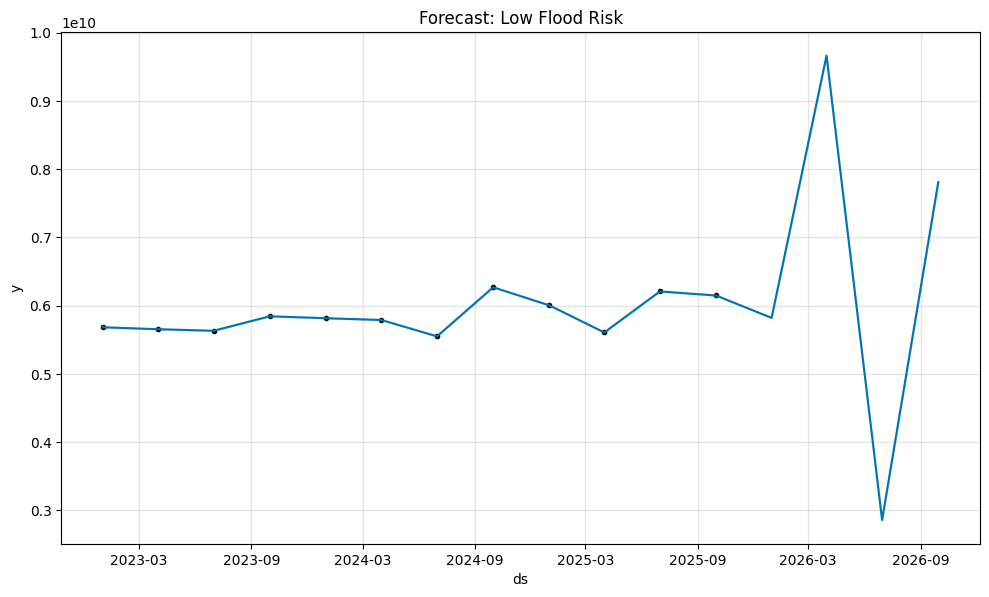

In [ ]:
flood_risks = ['High', 'Medium', 'Low']

for risk in flood_risks:
    df_risk = df[df['flood_risk'] == risk].groupby('quarter')['asset_value'].sum().reset_index()
    df_risk_prophet = df_risk.rename(columns={'quarter': 'ds', 'asset_value': 'y'})
    # Convert PeriodDtype to Timestamp
    df_risk_prophet['ds'] = df_risk_prophet['ds'].dt.to_timestamp()

    model = Prophet(yearly_seasonality=True)
    model.fit(df_risk_prophet)

    future = model.make_future_dataframe(periods=4, freq='Q')
    forecast = model.predict(future)

    model.plot(forecast)
    plt.title(f"Forecast: {risk} Flood Risk")
    plt.show()